# Noise model vs data: TM proxy parameters

Copy of `noise_model_vs_data.ipynb` for the **TM proxy parametrization** of the unequal-noise model
(`scripts/notes/TM_PROXY_PARAMS.md`). With one OMS and one TM amplitude per MOSA, the 6 TM amplitudes are
degenerate; the data constrain, per arm $k$ = 12, 23, 31 ($ij$ the clockwise MOSA):

- the **arm ASD** $A_k = \sqrt{(P_{ij} + P_{ji})/2}$ (well determined, ~2% per week of data),
- the **arm asymmetry** $\delta_k = (P_{ij} - P_{ji})/(P_{ij} + P_{ji}) \in (-1, 1)$ (two weak contrasts;
  the common shift of all three is exactly unidentifiable),

with $P = b^2$ the per-MOSA TM PSD level. The sampler works in `[S_oms x 6, A_12, A_23, A_31, d_12, d_23, d_31]`
and `make_tm_proxy_transform()` maps the TM slots back to per-MOSA amplitudes for the covariance.

1. Load the mojito noise-only data with the same preprocessing as `psd_multigpu_settings.py`.
2. Project it onto an FD grid with the same window.
3. Evaluate the pipeline XYZ covariance for the **equal** model and for the **unequal** model built from the
   true proxies through the transform.
4. Compare with the data periodogram.
5. Posterior predictive and marginals of sampler runs, in both the per-MOSA and the proxy basis, with the
   true proxies as truths.

In [1]:
import sys, importlib.util
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

from lisatools.detector import L1Orbits
from lisatools.domains import FDSettings
from lisatools.globalfit.preprocessing import L1ProcessingStep
from lisatools.sensitivity import (
    XYZSensitivityBackend,
    MOSA_NAMES,
    TM_PROXY_ARMS,
    make_tm_proxy_transform,
    tm_mosa_to_proxy,
)
from lisatools.utils.utility import windowfun


# Noise levels used in the mojito simulation (ASDs)
S_OMS = 15e-12   # m/sqrt(Hz)
S_TM = 3e-15     # m/s^2/sqrt(Hz)

# Per-MOSA injected amplitudes, keyed by link (orbits.LINKS order).
# Equal by default (mojito); perturb these to see the effect of unequal noises.
oms_asd_mosa = {m: S_OMS for m in MOSA_NAMES}
tm_asd_mosa = {m: S_TM for m in MOSA_NAMES}

# The same truths in the sampling basis: [S_oms x 6, A_12, A_23, A_31, d_12, d_23, d_31]
TM_TRANSFORM = make_tm_proxy_transform()
inj_mosa = np.array([oms_asd_mosa[m] for m in MOSA_NAMES] + [tm_asd_mosa[m] for m in MOSA_NAMES])
inj_proxy = np.concatenate([inj_mosa[:6], tm_mosa_to_proxy(*inj_mosa[6:])])
PROXY_LABELS = [rf"$A_{{\rm tm,{k}}}$" for k in TM_PROXY_ARMS] + [rf"$\delta_{{\rm tm,{k}}}$" for k in TM_PROXY_ARMS]
print("true TM proxies:", dict(zip(PROXY_LABELS, inj_proxy[6:])))

def to_np(x):
    return x.get() if hasattr(x, "get") else np.asarray(x)

true TM proxies: {'$A_{\\rm tm,12}$': np.float64(3e-15), '$A_{\\rm tm,23}$': np.float64(3e-15), '$A_{\\rm tm,31}$': np.float64(3e-15), '$\\delta_{\\rm tm,12}$': np.float64(0.0), '$\\delta_{\\rm tm,23}$': np.float64(0.0), '$\\delta_{\\rm tm,31}$': np.float64(0.0)}


## 1. Load and preprocess the data

Values copied from `mojito_input/psd_multigpu_settings.py`. The settings module isn't
imported directly because that would pull in `lisatools.globalfit.run` and the GB moves.

In [2]:
L1_FOLDER = "/mnt/wd_hdd_6TB/nikos/DATA/global_fit/mojito_lite/"
BACKEND = "cuda12x"            # or "cpu"
TOBS = 7.0 * 24 * 3600.0
DT = 5.0
START_FREQ, END_FREQ = 1e-4, 1e-1
WINDOW_TYPE, WINDOW_TAPER = "tukey", 1 / START_FREQ
SENS_KWARGS = dict(tdi_generation=2, mask_percentage=0.02, average_transfer_functions=True)

proc = L1ProcessingStep(
    L1_folder=L1_FOLDER,
    source_types=["noise"],
    verbose=False,
    do_plots=False,
    orbits_class=L1Orbits,
    orbits_kwargs=dict(force_backend=BACKEND, frame="icrs"),
)
times, _ = proc.process(
    highpass_kwargs=dict(cutoff=5e-6, order=2, zero_phase=True),
    lowpass_kwargs=dict(cutoff=0.101, order=2, zero_phase=True),
    trim_kwargs=dict(duration=0.02, is_percent=True, trimming_type="from_each_end"),
    downsample_kwargs=dict(target_fs=1 / DT, window=("kaiser", 5.0)),
    Tobs=TOBS,
)

[load_data] L1Orbits(...) (incl. _setup) took 0.86s
[load_data] orbits._ensure_configured() took 2.07s


2026-10-06 10:03:42,992 - lisatools.globalfit.preprocessing - INFO - Initialized orbits from NOISE file.


[load_data] NOISE f.tdis.xyz_doppler[:] took 0.48s shape=(25246480, 3)


## 2. FD projection with the pipeline window

In [3]:
Nt = len(times)
dt = proc.td_signal.settings.dt
fd_settings = FDSettings.make_factory(min_freq=START_FREQ, max_freq=END_FREQ)(
    times=times, dt=dt, force_backend=BACKEND
)
window, _ = windowfun(WINDOW_TYPE, Nt, alpha=WINDOW_TAPER / (Nt * dt))
window = fd_settings.xp.asarray(window)   # same array module as the data

data, orbits = proc.pour(settings=fd_settings, window=window, return_orbits=True)
d = to_np(data.arr)                 # (3, Nf), d~ = dt * rfft(x * w)
f = to_np(fd_settings.f_arr)
df = fd_settings.df

# Periodogram with the likelihood's convention: E[2 df d_i d_j^*] = C_ij
P_data = 2 * df * np.einsum("if,jf->ijf", d, d.conj())
print(d.shape, f[0], f[-1], df)

(3, 60420) 0.00010085978835978836 0.1 1.6534391534391535e-06


/home/karnesis/anaconda3/envs/erebor_env/lib/python3.12/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


## 3. Pipeline noise models

`noise_normalization` (window power x filter response) is applied inside the kernel.
The filter response is passed explicitly here, because the data really are band-pass filtered.
The unequal model is evaluated from the **true proxies through the transform**, exactly as the sampler does,
and checked against the direct per-MOSA evaluation.

In [4]:
filters_response = proc.get_total_response(f)
alias = proc.get_alias_response(f)   # downsampling alias terms (alias_correction=True by default)

def make_backend(noise_symmetry):
    return XYZSensitivityBackend(
        orbits=orbits,
        settings=fd_settings,
        force_backend=BACKEND,
        window_values=window,
        filters_response=filters_response,
        alias_frequencies=None if alias is None else alias[0],
        alias_filters_response=None if alias is None else alias[1],
        noise_symmetry=noise_symmetry,
        **SENS_KWARGS,
    )

backend_equal = make_backend("symmetric")
backend_unequal = make_backend("asymmetric")

C_equal = to_np(backend_equal.compute_sensitivity_matrix(S_OMS, S_TM)).reshape(3, 3, -1)

# sampling basis -> per-MOSA amplitudes -> covariance (the path the PSD moves take)
Soms_inj, Sa_inj, _ = backend_unequal.split_psd_params(TM_TRANSFORM.both_transforms(inj_proxy))
C_unequal = to_np(backend_unequal.compute_sensitivity_matrix(Soms_inj, Sa_inj)).reshape(3, 3, -1)

C_unequal_direct = to_np(backend_unequal.compute_sensitivity_matrix(inj_mosa[:6], inj_mosa[6:])).reshape(3, 3, -1)
print("proxy path vs direct per-MOSA, max rel diff:",
      np.max(np.abs(C_unequal - C_unequal_direct)) / np.max(np.abs(C_unequal_direct)))

proxy path vs direct per-MOSA, max rel diff: 0.0


## 4. Compare with the data

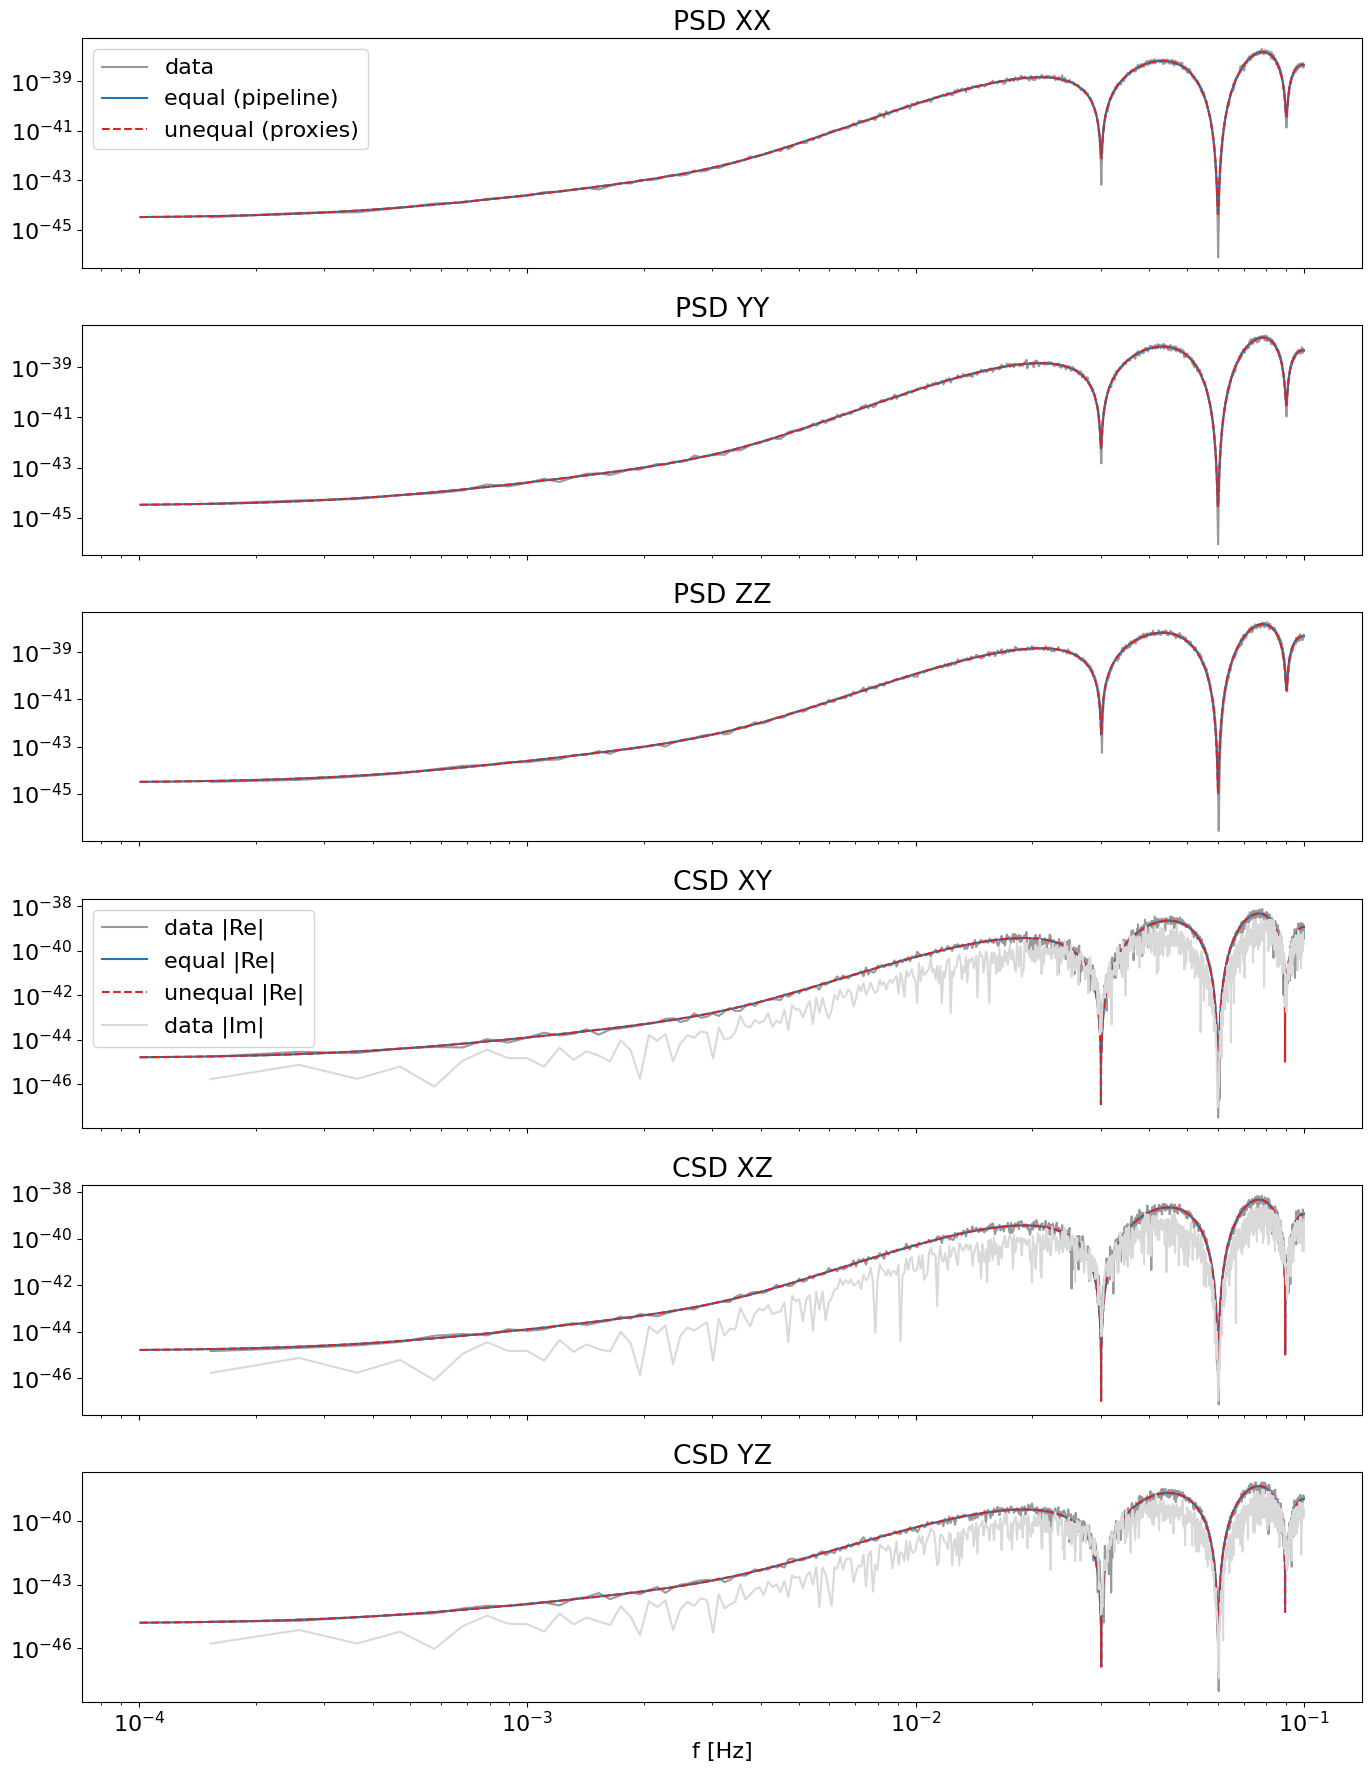

In [5]:
def bin_avg(x, n=64):
    m = (x.shape[-1] // n) * n
    return x[..., :m].reshape(*x.shape[:-1], -1, n).mean(-1)

fb = bin_avg(f)
labels = "XYZ"
pairs_auto = [(0, 0), (1, 1), (2, 2)]
pairs_cross = [(0, 1), (0, 2), (1, 2)]

fig, axes = plt.subplots(6, 1, figsize=(14, 18), sharex=True)
for ax, (i, j) in zip(axes[:3], pairs_auto):
    ax.loglog(fb, bin_avg(P_data[i, j].real), color="0.6", label="data")
    ax.loglog(f, C_equal[i, j].real, "C0", label="equal (pipeline)")
    ax.loglog(f, C_unequal[i, j].real, "C3--", label="unequal (proxies)")
    ax.set_title(f"PSD {labels[i]}{labels[j]}")
for ax, (i, j) in zip(axes[3:], pairs_cross):
    ax.loglog(fb, np.abs(bin_avg(P_data[i, j].real)), color="0.6", label="data |Re|")
    ax.loglog(f, np.abs(C_equal[i, j].real), "C0", label="equal |Re|")
    ax.loglog(f, np.abs(C_unequal[i, j].real), "C3--", label="unequal |Re|")
    ax.loglog(fb, np.abs(bin_avg(P_data[i, j].imag)), color="0.85", label="data |Im|")
    ax.set_title(f"CSD {labels[i]}{labels[j]}")
axes[-1].set_xlabel("f [Hz]")
axes[0].legend(); axes[3].legend()
fig.tight_layout()

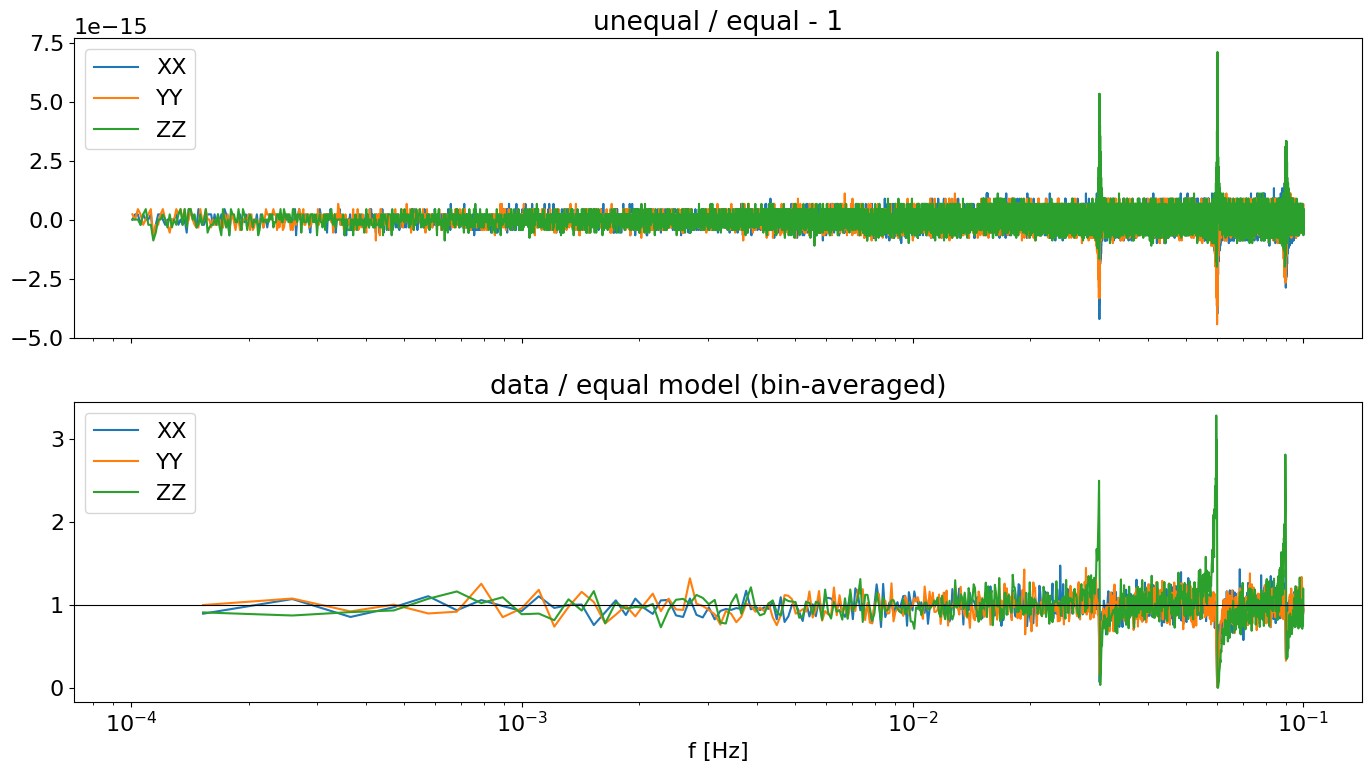

In [6]:
# Model-vs-model and data-vs-model ratios (auto-PSDs)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for (i, j) in pairs_auto:
    axes[0].semilogx(f, C_unequal[i, j].real / C_equal[i, j].real - 1, label=f"{labels[i]}{labels[j]}")
    axes[1].semilogx(fb, bin_avg(P_data[i, j].real) / bin_avg(C_equal[i, j].real), label=f"{labels[i]}{labels[j]}")
axes[0].set_title("unequal / equal - 1")
axes[1].set_title("data / equal model (bin-averaged)")
axes[1].axhline(1, color="k", lw=0.8)
axes[-1].set_xlabel("f [Hz]")
for ax in axes:
    ax.legend()
fig.tight_layout()

## 5. Posterior predictive from sampler runs

Load PSD chains from disk, draw random samples from the cold chain (after burn-in) and evaluate the
noise covariance for each draw on the FD grid above. The reconstructions are summarised by their median
and a quantile band, plotted over the data and the injection model (`C_equal` at the injected `S_OMS`, `S_TM`).

Symmetric runs have 2 parameters; asymmetric runs have 12, sampled either per MOSA (`"mosa"`, older runs) or in
the proxy basis (`"proxy"`, `TM_PARAMETRIZATION = "proxy"` in the settings). Both have 12 columns, so the basis is
guessed from the asymmetry columns (proxies have $|\delta_k| \sim 0.01$–$1$, amplitudes are $\sim 10^{-15}$);
set `RUN_BASIS[name]` to override. Every asymmetric chain is converted to both bases.
The runs may have used the STFT basis; the amplitudes are basis-independent, so evaluating them on the
FD grid is a fair comparison with the FD periodogram.

In [7]:
import glob, os
import h5py

RUNS_DIRS = [
    "/mnt/wd_hdd_6TB/nikos/DATA/global_fit/gf_output/unequal_noises_preproc-bias_inv_fmax:1.0e-01/",
    # add the proxy-parametrized run directories here
]
RUN_BASIS = {}       # optional override {run name: "mosa" | "proxy"}
BURN_FRAC = 0.5      # fraction of iterations discarded
N_DRAWS = 200        # posterior draws per run
QUANTILES = (0.05, 0.95)
CHUNK = 50           # draws per kernel call (GPU memory)
rng = np.random.default_rng(1234)

def load_psd_chain(path, burn_frac=BURN_FRAC, temp=0):
    """Cold-chain PSD samples, shape (n_samples, ndim)."""
    with h5py.File(path, "r") as fh:
        group = fh["global_fit"] if "global_fit" in fh else fh["mcmc"]
        chain = group["chain/psd"][:, temp, :, 0, :]   # (iter, walker, ndim)
        inds = group["inds/psd"][:, temp, :, 0]
        log_like = group["log_like"][:, temp, :]
        iteration = int(group.attrs["iteration"])
    chain, inds, log_like = chain[:iteration], inds[:iteration], log_like[:iteration]
    start = int(burn_frac * iteration)
    keep = inds[start:]
    return chain[start:][keep], log_like[start:][keep]

def guess_basis(samples):
    if samples.shape[1] != 2 * len(MOSA_NAMES):
        return "symmetric"
    return "proxy" if np.max(np.abs(samples[:, 9:])) > 1e-6 else "mosa"

def mosa_to_proxy_samples(s):
    return np.column_stack([s[:, :6], *tm_mosa_to_proxy(*s[:, 6:].T)])

run_files = sorted(
    f for d in RUNS_DIRS for f in glob.glob(os.path.join(d, "*_main.h5")) if "backup" not in f
)
chains, chains_proxy, bases = {}, {}, {}
for fp in run_files:
    name = os.path.basename(fp).replace("_parameter_estimation_main.h5", "")
    raw, _ = load_psd_chain(fp)
    bases[name] = RUN_BASIS.get(name, guess_basis(raw))
    if bases[name] == "proxy":
        chains_proxy[name], chains[name] = raw, TM_TRANSFORM.both_transforms(raw)
    elif bases[name] == "mosa":
        chains[name], chains_proxy[name] = raw, mosa_to_proxy_samples(raw)
    else:
        chains[name] = raw
    print(f"{name}: {raw.shape[0]} samples, ndim={raw.shape[1]}, sampled in the {bases[name]!r} basis")

unequal_noises_preproc-bias_inv_stft: 7500 samples, ndim=12, sampled in the 'mosa' basis


In [8]:
backends = {2: backend_equal, 2 * len(MOSA_NAMES): backend_unequal}

def posterior_predictive(samples, n_draws=N_DRAWS, chunk=CHUNK):
    """Covariances for random draws of per-MOSA samples, shape (n_draws, 3, 3, Nf)."""
    backend = backends[samples.shape[1]]
    draws = samples[rng.choice(len(samples), size=min(n_draws, len(samples)), replace=False)]
    out = []
    for k in range(0, len(draws), chunk):
        Soms, Sa, _ = backend.split_psd_params(draws[k : k + chunk])
        C = to_np(backend.compute_sensitivity_matrix(Soms, Sa))
        out.append(C.reshape(len(Soms), 3, 3, -1))
    return draws, np.concatenate(out)

ppd = {name: posterior_predictive(s) for name, s in chains.items()}

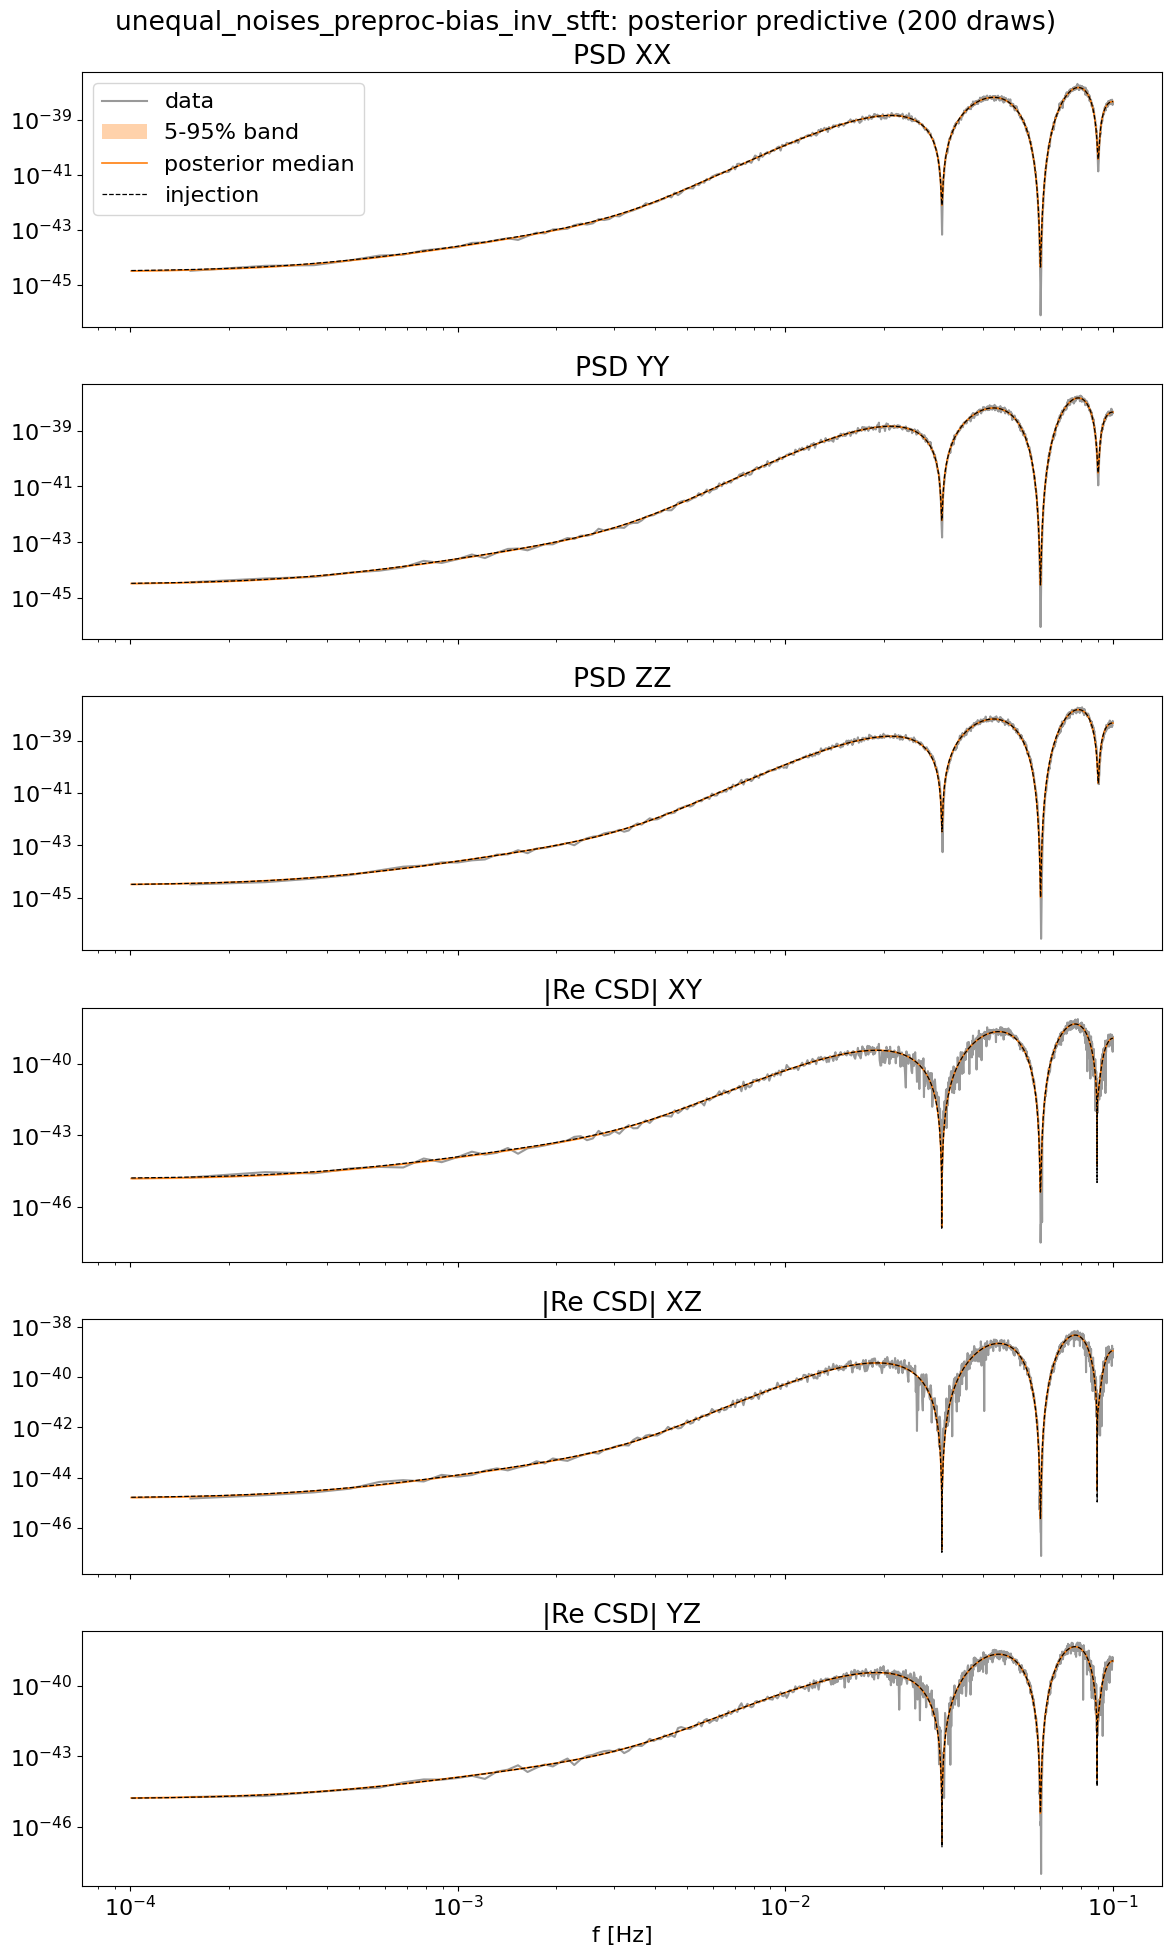

In [9]:
def ppd_bands(C_draws, q=QUANTILES):
    """Median and quantile band of the auto PSDs (real) and |Re| of the CSDs."""
    vals = {}
    for (i, j) in pairs_auto + pairs_cross:
        x = C_draws[:, i, j].real
        x = x if i == j else np.abs(x)
        vals[(i, j)] = (np.median(x, axis=0), *np.quantile(x, q, axis=0))
    return vals

for name, (draws, C_draws) in ppd.items():
    bands = ppd_bands(C_draws)
    fig, axes = plt.subplots(6, 1, figsize=(12, 20), sharex=True)
    for ax, (i, j) in zip(axes.ravel(), pairs_auto + pairs_cross):
        data_ij = bin_avg(P_data[i, j].real)
        inj_ij = C_equal[i, j].real
        if i != j:
            data_ij, inj_ij = np.abs(data_ij), np.abs(inj_ij)
        med, lo, hi = bands[(i, j)]
        ax.loglog(fb, data_ij, color="0.6", label="data")
        ax.fill_between(f, lo, hi, color="C1", alpha=0.35, lw=0,
                        label=f"{int(100 * QUANTILES[0])}-{int(100 * QUANTILES[1])}% band")
        ax.loglog(f, med, "C1", lw=1.2, label="posterior median")
        ax.loglog(f, inj_ij, "k--", lw=0.9, label="injection")
        kind = "PSD" if i == j else "|Re CSD|"
        ax.set_title(f"{kind} {labels[i]}{labels[j]}")
    axes[-1].set_xlabel("f [Hz]")
    axes[0].legend()
    fig.suptitle(f"{name}: posterior predictive ({len(draws)} draws)")
    fig.tight_layout()

Relative deviation of the reconstructions from the injection model (auto PSDs). Values near zero
across the band mean the posterior predictive reproduces the injected spectra, even when the individual
per-MOSA amplitudes are degenerate.

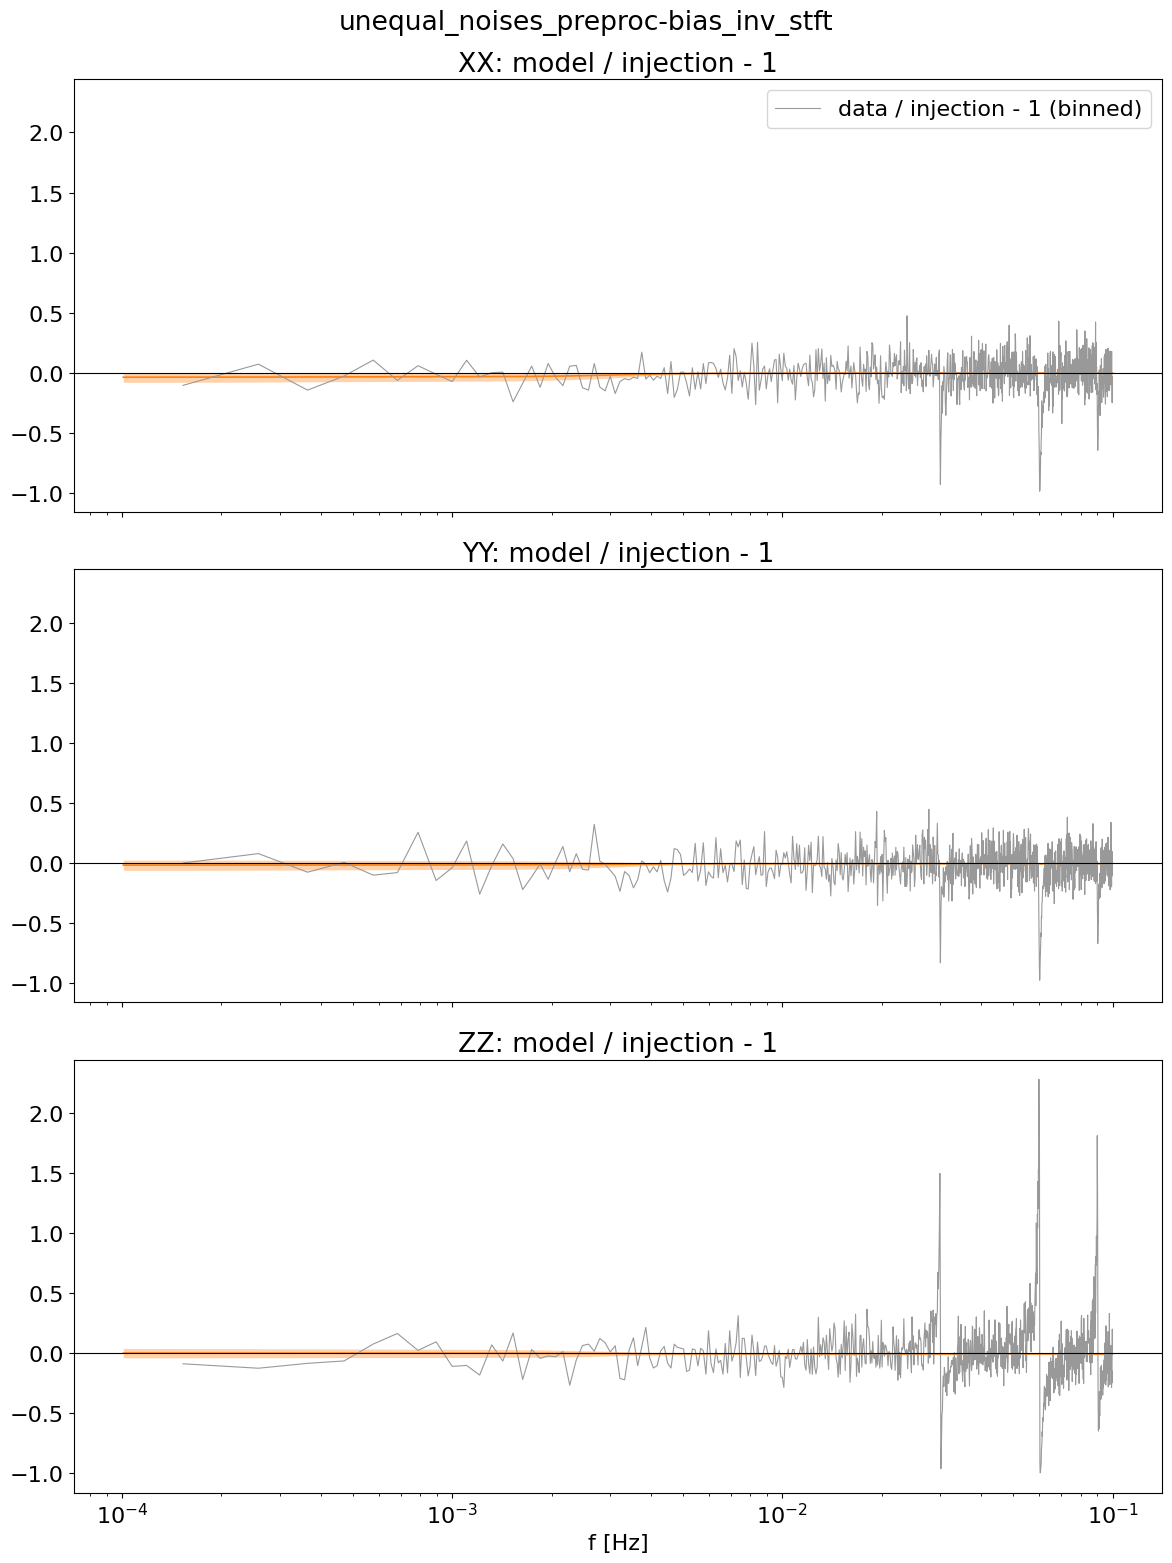

In [10]:
for name, (draws, C_draws) in ppd.items():
    fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=True, sharey=True)
    for ax, (i, j) in zip(axes, pairs_auto):
        rel = C_draws[:, i, j].real / C_equal[i, j].real - 1
        lo, med, hi = np.quantile(rel, (QUANTILES[0], 0.5, QUANTILES[1]), axis=0)
        ax.fill_between(f, lo, hi, color="C1", alpha=0.35, lw=0)
        ax.semilogx(f, med, "C1", lw=1.2)
        ax.semilogx(fb, bin_avg(P_data[i, j].real) / bin_avg(C_equal[i, j].real) - 1,
                    color="0.6", lw=0.8, label="data / injection - 1 (binned)")
        ax.axhline(0, color="k", lw=0.8)
        ax.set_title(f"{labels[i]}{labels[j]}: model / injection - 1")
    axes[-1].set_xlabel("f [Hz]")
    axes[0].legend()
    fig.suptitle(name)
    fig.tight_layout()

## 6. Marginals: per-MOSA vs proxy basis

Top row: per-MOSA amplitudes relative to the injection (`S / S_inj`), as in the original notebook.
Bottom row: the same samples in the proxy basis, $A_k / A_{k,\rm inj}$ and $\delta_k - \delta_{k,\rm inj}$.
The per-MOSA TM boxes are broad; the arm ASDs are tight.

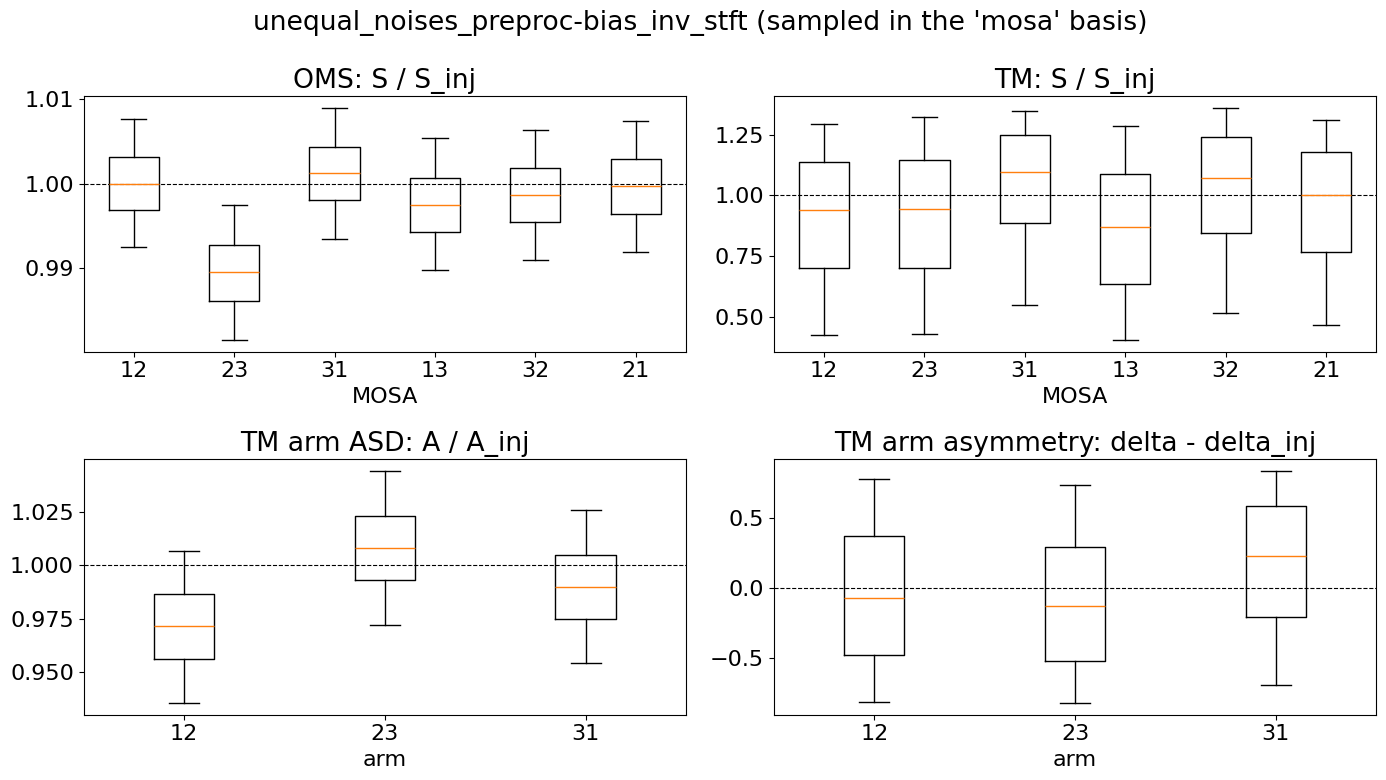

In [11]:
for name, samples in chains.items():
    backend = backends[samples.shape[1]]
    Soms, Sa, _ = backend.split_psd_params(samples)
    Soms, Sa = np.atleast_2d(Soms.T).T, np.atleast_2d(Sa.T).T     # (n_samples, n)
    names = MOSA_NAMES if Soms.shape[1] > 1 else ["all"]
    has_proxy = name in chains_proxy
    fig, axes = plt.subplots(2 if has_proxy else 1, 2, figsize=(14, 8 if has_proxy else 4), squeeze=False)
    for ax, vals, inj, title in ((axes[0, 0], Soms, S_OMS, "OMS"), (axes[0, 1], Sa, S_TM, "TM")):
        ax.boxplot(vals / inj, whis=(5, 95), showfliers=False)
        ax.set_xticks(range(1, len(names) + 1), names)
        ax.axhline(1, color="k", lw=0.8, ls="--")
        ax.set_title(f"{title}: S / S_inj")
        ax.set_xlabel("MOSA")
    if has_proxy:
        P = chains_proxy[name]
        for ax, vals, ref, title, ylab in (
            (axes[1, 0], P[:, 6:9] / inj_proxy[6:9], 1.0, "TM arm ASD: A / A_inj", "A / A_inj"),
            (axes[1, 1], P[:, 9:] - inj_proxy[9:], 0.0, "TM arm asymmetry: delta - delta_inj", "delta - delta_inj"),
        ):
            ax.boxplot(vals, whis=(5, 95), showfliers=False)
            ax.set_xticks(range(1, 4), TM_PROXY_ARMS)
            ax.axhline(ref, color="k", lw=0.8, ls="--")
            ax.set_title(title)
            ax.set_xlabel("arm")
    fig.suptitle(f"{name} (sampled in the {bases[name]!r} basis)")
    fig.tight_layout()

## 7. Corner plots of the TM parameters

Same samples, per-MOSA basis (left figure) and proxy basis (right figure). Truths are the injected values in
each basis (`inj_mosa`, `inj_proxy`). Arm partners (12/21, 23/32, 31/13) are strongly anti-correlated per MOSA;
in the proxy basis the arm ASDs are nearly independent and the asymmetries carry the degeneracy.

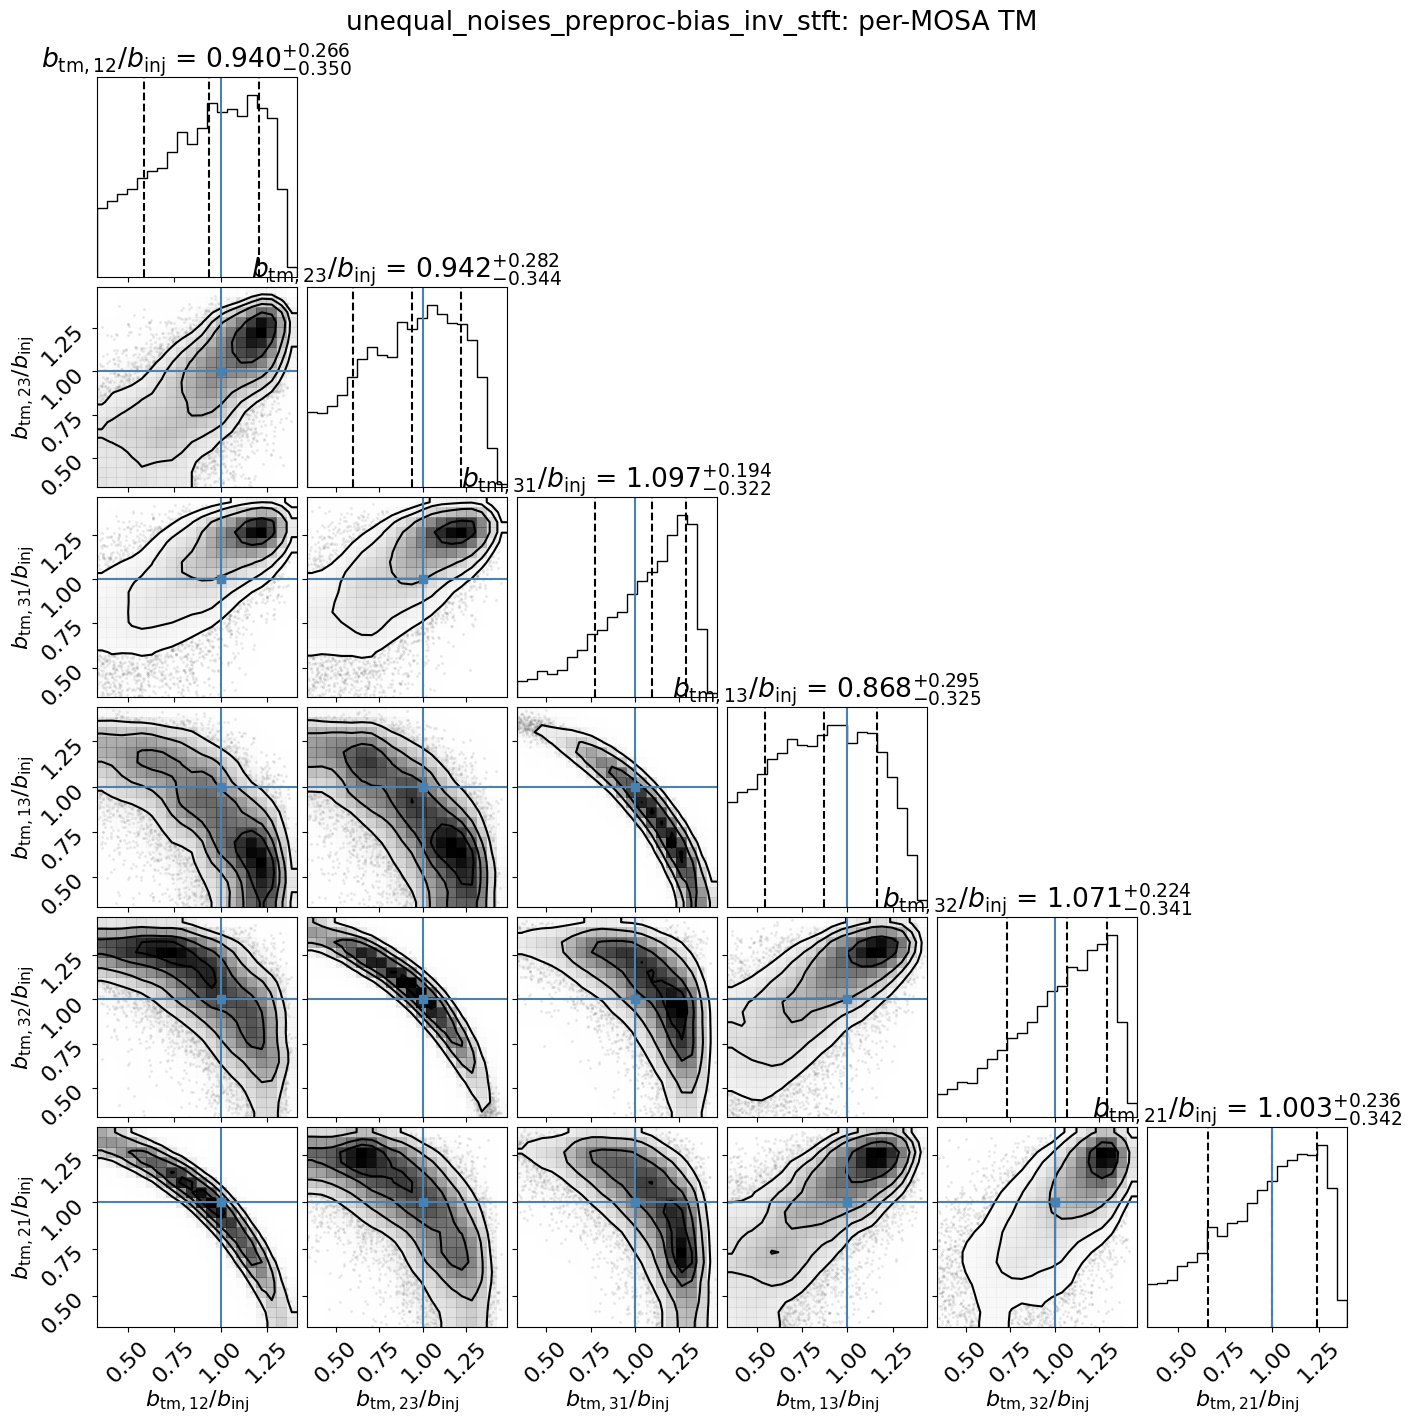

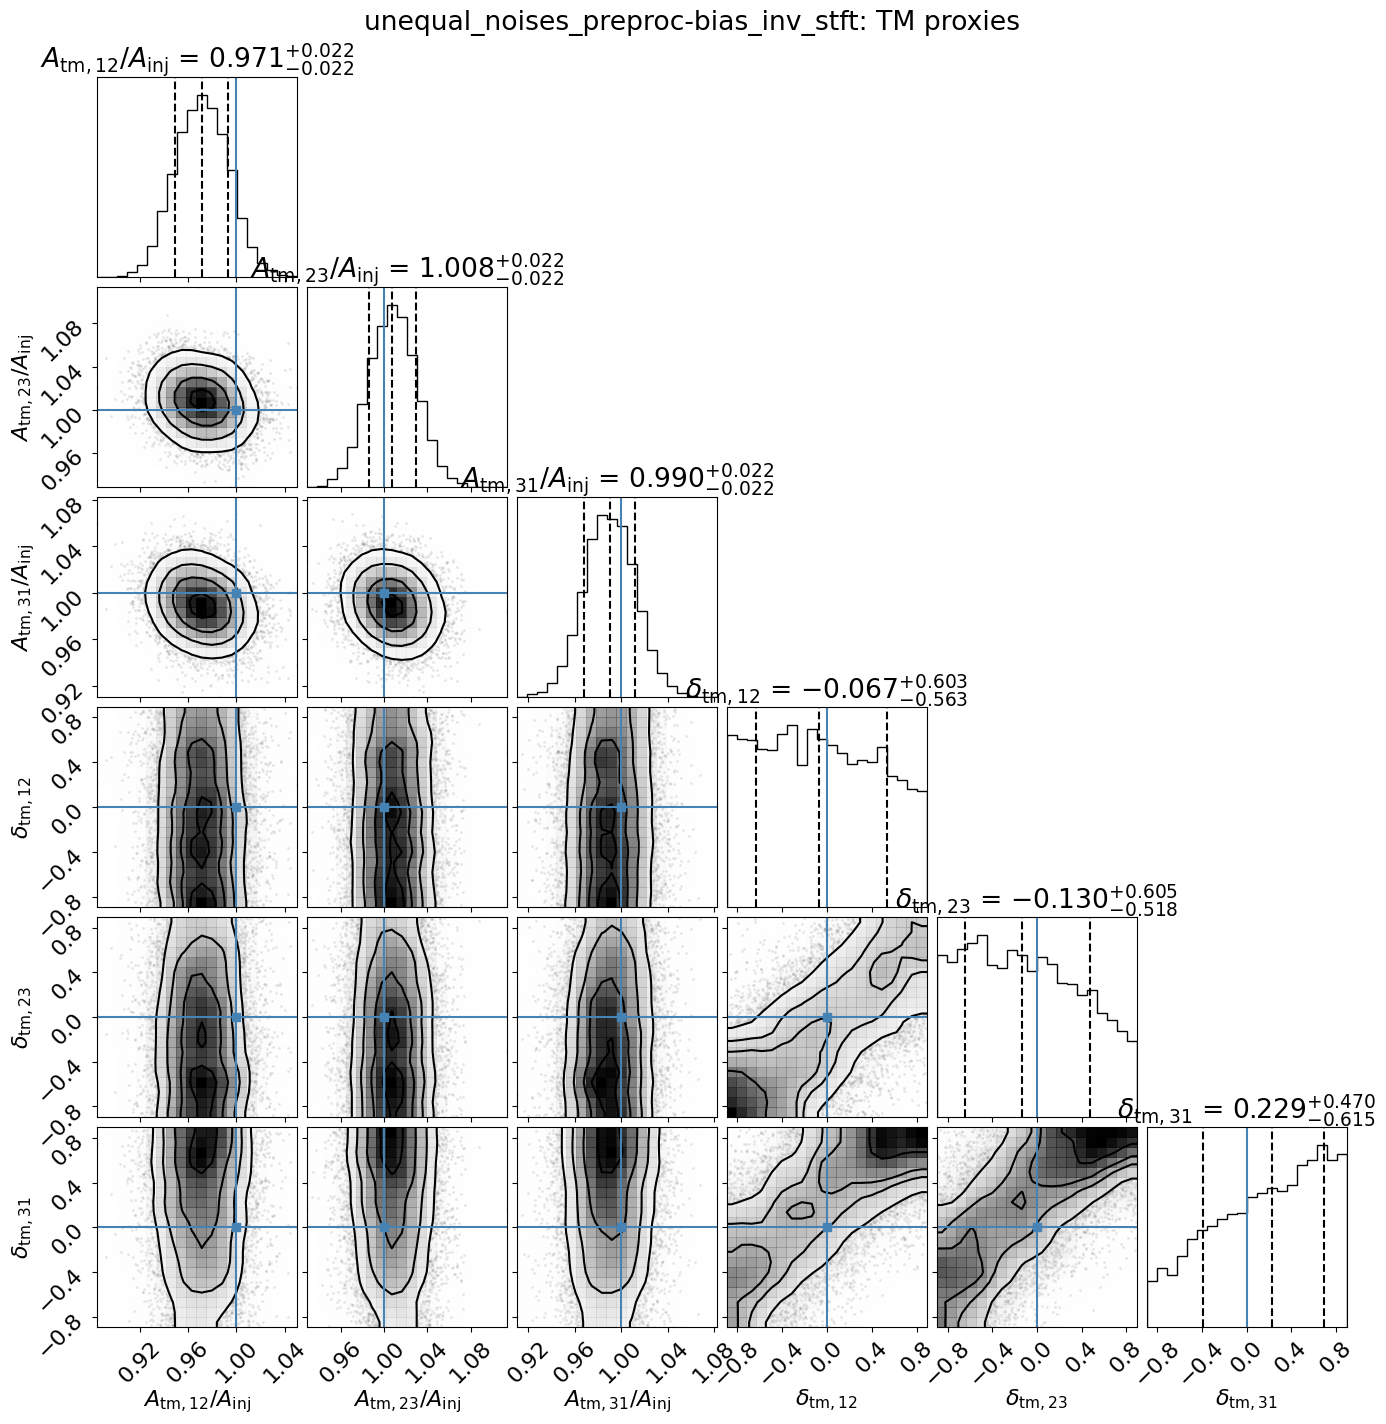

In [12]:
import corner

for name in chains_proxy:
    tm_mosa = chains[name][:, 6:] / S_TM
    fig1 = corner.corner(tm_mosa, labels=[rf"$b_{{\rm tm,{m}}}/b_{{\rm inj}}$" for m in MOSA_NAMES],
                         truths=inj_mosa[6:] / S_TM, quantiles=(0.16, 0.5, 0.84), show_titles=True,
                         title_fmt=".3f", smooth=1.0)
    fig1.suptitle(f"{name}: per-MOSA TM", y=1.02)

    tm_proxy = np.column_stack([chains_proxy[name][:, 6:9] / inj_proxy[6:9], chains_proxy[name][:, 9:]])
    fig2 = corner.corner(tm_proxy, labels=[rf"$A_{{\rm tm,{k}}}/A_{{\rm inj}}$" for k in TM_PROXY_ARMS] + PROXY_LABELS[3:],
                         truths=np.concatenate([np.ones(3), inj_proxy[9:]]), quantiles=(0.16, 0.5, 0.84),
                         show_titles=True, title_fmt=".3f", smooth=1.0)
    fig2.suptitle(f"{name}: TM proxies", y=1.02)

Summary in the proxy basis: posterior median and std against the truth, plus the two identifiable
asymmetry contrasts ($\delta_{12}-\delta_{23}$, $\delta_{23}-\delta_{31}$; the null direction shifts all
$A_k^2\delta_k$ equally, so these are invariant only when the arm ASDs are equal) and the
standard deviation of the per-MOSA TM amplitudes for comparison.

In [13]:
for name, P in chains_proxy.items():
    print(f"=== {name} ({bases[name]} basis) ===")
    print(f"{'parameter':>12s} {'truth':>11s} {'median':>11s} {'std':>10s} {'(med-truth)/std':>16s}")
    rows = [(f"S_oms_{m}", i) for i, m in enumerate(MOSA_NAMES)] + \
           [(f"A_tm_{k}", 6 + i) for i, k in enumerate(TM_PROXY_ARMS)] + \
           [(f"d_tm_{k}", 9 + i) for i, k in enumerate(TM_PROXY_ARMS)]
    for label, i in rows:
        med, std = np.median(P[:, i]), np.std(P[:, i])
        print(f"{label:>12s} {inj_proxy[i]:11.4e} {med:11.4e} {std:10.3e} {(med - inj_proxy[i]) / std:16.2f}")
    for a, b in ((0, 1), (1, 2)):
        c = P[:, 9 + a] - P[:, 9 + b]
        t = inj_proxy[9 + a] - inj_proxy[9 + b]
        print(f"  d_{TM_PROXY_ARMS[a]} - d_{TM_PROXY_ARMS[b]}: truth {t:+.3f}, median {np.median(c):+.3f}, std {np.std(c):.3f}")
    print("  per-MOSA TM std / S_inj:", np.round(np.std(chains[name][:, 6:], axis=0) / S_TM, 3))

=== unequal_noises_preproc-bias_inv_stft (mosa basis) ===
   parameter       truth      median        std  (med-truth)/std
    S_oms_12  1.5000e-11  1.5000e-11  6.978e-14             0.00
    S_oms_23  1.5000e-11  1.4842e-11  7.360e-14            -2.14
    S_oms_31  1.5000e-11  1.5018e-11  7.064e-14             0.26
    S_oms_13  1.5000e-11  1.4961e-11  7.100e-14            -0.55
    S_oms_32  1.5000e-11  1.4979e-11  7.101e-14            -0.29
    S_oms_21  1.5000e-11  1.4995e-11  7.099e-14            -0.07
     A_tm_12  3.0000e-15  2.9141e-15  6.604e-17            -1.30
     A_tm_23  3.0000e-15  3.0236e-15  6.579e-17             0.36
     A_tm_31  3.0000e-15  2.9698e-15  6.590e-17            -0.46
     d_tm_12  0.0000e+00 -6.7218e-02  5.006e-01            -0.13
     d_tm_23  0.0000e+00 -1.3013e-01  4.884e-01            -0.27
     d_tm_31  0.0000e+00  2.2851e-01  4.791e-01             0.48
  d_12 - d_23: truth +0.000, median +0.046, std 0.425
  d_23 - d_31: truth +0.000, median -0.247,